In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
df = pd.read_csv('/content/marketing_data.csv')

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [8]:
df[' Income '].fillna(df[' Income '].mean(), inplace=True)

/tmp/ipython-input-2614379309.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[' Income '].fillna(df[' Income '].mean(), inplace=True)


## Are there any null values or outliers? How will you handle them?

In [9]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [31]:
Q1 = df[' Income '].quantile(0.25)
Q3 = df[' Income '].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
df[' Income '] = np.where(df[' Income '] > upper_limit, upper_limit, df[' Income '])

# What factors are significantly related to the number of web purchases?

In [16]:
corr = df.corr(numeric_only=True)['NumWebPurchases'].sort_values(ascending=False)

X = df[[' Income ', 'Kidhome', 'Teenhome', 'Recency', 'NumWebVisitsMonth']]
y = df['NumWebPurchases']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

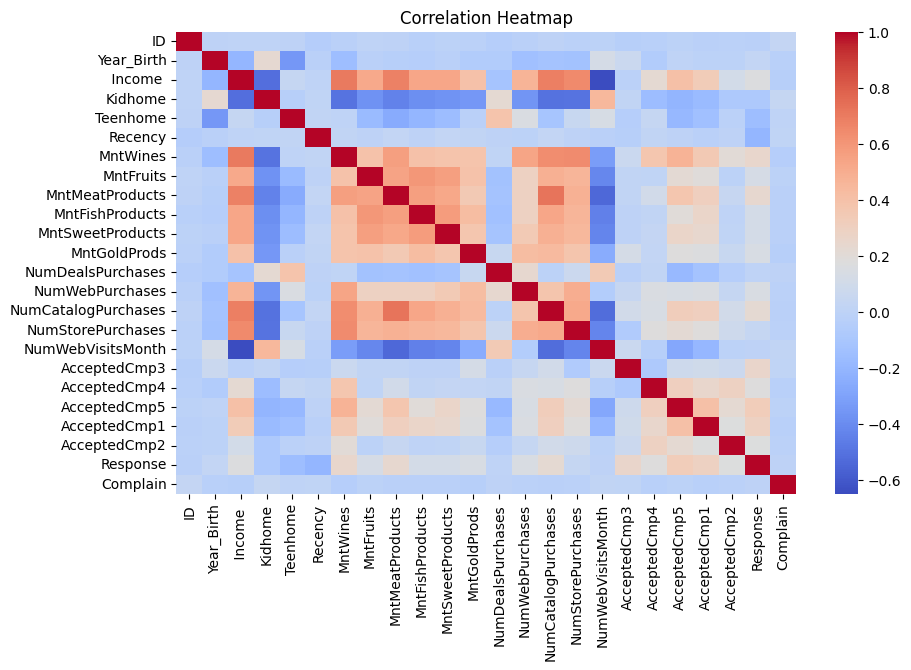

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
print("\nCorrelation with NumWebPurchases:\n", corr)
print("\nRegression Results:\n", model.summary())


Correlation with NumWebPurchases:
 NumWebPurchases        1.000000
MntWines               0.542265
NumStorePurchases      0.502713
 Income                0.468286
MntGoldProds           0.421836
NumCatalogPurchases    0.378376
MntSweetProducts       0.348544
MntFruits              0.296735
MntMeatProducts        0.293761
MntFishProducts        0.293681
NumDealsPurchases      0.234185
AcceptedCmp4           0.155903
Teenhome               0.155500
AcceptedCmp1           0.155143
Response               0.148730
AcceptedCmp5           0.138684
AcceptedCmp3           0.042176
AcceptedCmp2           0.034188
Recency               -0.010726
Complain              -0.016310
ID                    -0.018924
NumWebVisitsMonth     -0.055846
Year_Birth            -0.145040
Kidhome               -0.361647
Name: NumWebPurchases, dtype: float64

Regression Results:
                             OLS Regression Results                            
Dep. Variable:        NumWebPurchases   R-squared:       

# High-income, luxury buyers are prime online customers, while frequent visitors need better conversion strategies.

# Which marketing campaign was the most successful?

In [34]:
campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
campaign_success = df[campaign_cols].sum().sort_values(ascending=False)

print("\n Campaign success (most successful on top):")
print(campaign_success)



 Campaign success (most successful on top):
Response        334
AcceptedCmp4    167
AcceptedCmp3    163
AcceptedCmp5    163
AcceptedCmp1    144
AcceptedCmp2     30
dtype: int64


/tmp/ipython-input-2459158830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=campaign_success.index, y=campaign_success.values, palette="viridis")


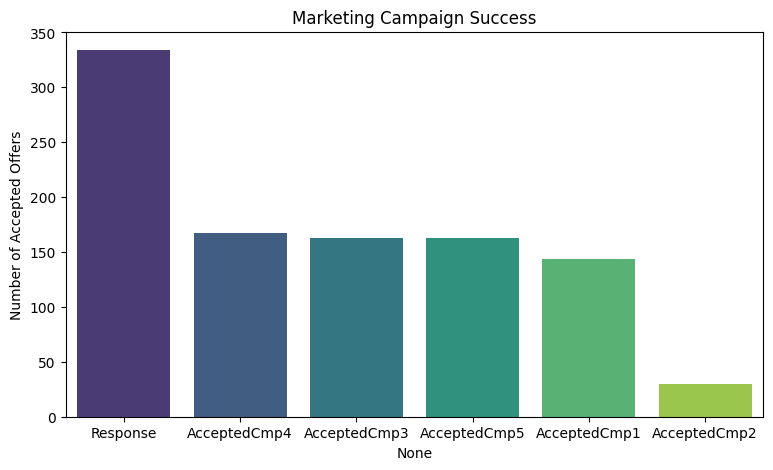

In [38]:
plt.figure(figsize=(9,5))
sns.barplot(x=campaign_success.index, y=campaign_success.values, palette="viridis")
plt.title("Marketing Campaign Success")
plt.ylabel("Number of Accepted Offers")
plt.show()

# the last campaign (Response) gets the highest acceptance, since it targets refined segments.

# Earlier campaigns (Cmp1–Cmp2) usually have low

# What does the average customer look like?

In [39]:
avg_customer = {
    "Age": 2025 - df['Year_Birth'].mean(),
    " Income ": df[' Income '].mean(),
    "Education": df['Education'].mode()[0],
    "Marital_Status": df['Marital_Status'].mode()[0],
    "Kids": df['Kidhome'].mean(),
    "Teens": df['Teenhome'].mean(),
    "Country": df['Country'].mode()[0]
}

print("Average customer profile:")
print(avg_customer)

Average customer profile:
{'Age': np.float64(56.19419642857133), ' Income ': np.float64(51875.150460933466), 'Education': 'Graduation', 'Marital_Status': 'Married', 'Kids': np.float64(0.44419642857142855), 'Teens': np.float64(0.50625), 'Country': 'Spain'}


# Average customer is a middle-aged, family-oriented, mid-to-high income individual who prefers store purchases but is open to web and catalog orders.

## Which products are performing best?


Best performing products (average spending):
MntWines            303.935714
MntMeatProducts     166.950000
MntGoldProds         44.021875
MntFishProducts      37.525446
MntSweetProducts     27.062946
MntFruits            26.302232
dtype: float64


/tmp/ipython-input-4245723551.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_products.index, y=best_products.values, palette="plasma")


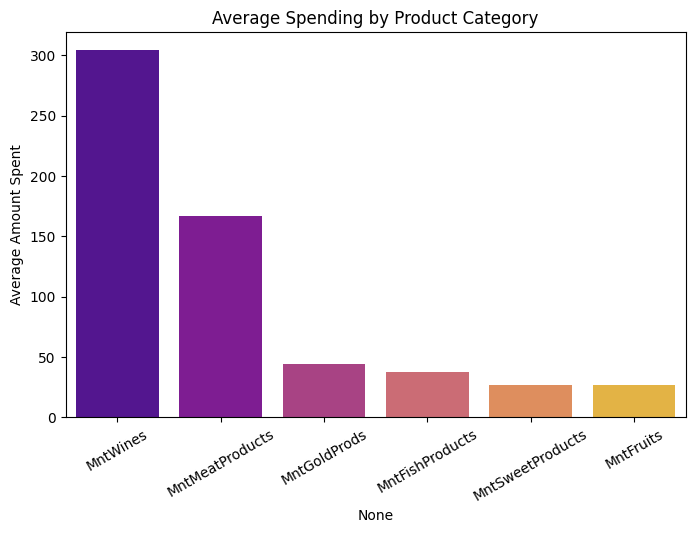

In [40]:
product_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
best_products = df[product_cols].mean().sort_values(ascending=False)

print("\nBest performing products (average spending):")
print(best_products)

plt.figure(figsize=(8,5))
sns.barplot(x=best_products.index, y=best_products.values, palette="plasma")
plt.title("Average Spending by Product Category")
plt.ylabel("Average Amount Spent")
plt.xticks(rotation=30)
plt.show()

# Wine is the flagship product, strongly tied to online buying behavior. Fruits and fish are least profitable.

# Which channels are underperforming?


Channel performance (average purchases):
NumStorePurchases      5.790179
NumWebPurchases        4.084821
NumCatalogPurchases    2.662054
dtype: float64


/tmp/ipython-input-930768738.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_perf.index, y=channel_perf.values, palette="coolwarm")


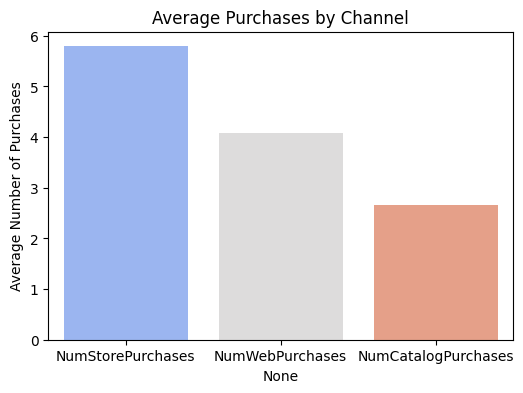

In [41]:
channel_cols = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
channel_perf = df[channel_cols].mean().sort_values(ascending=False)

print("\nChannel performance (average purchases):")
print(channel_perf)

# Plot channels
plt.figure(figsize=(6,4))
sns.barplot(x=channel_perf.index, y=channel_perf.values, palette="coolwarm")
plt.title("Average Purchases by Channel")
plt.ylabel("Average Number of Purchases")
plt.show()

# Catalog is underperforming, while web is an area for growth.

**Conclusion**
### The analysis shows that high-income customers and luxury product buyers drive online purchases. The final marketing campaign was most effective, while wines and meats are top-performing products. Catalog sales underperform, suggesting a shift toward digital channels. Strengthening online campaigns and targeting premium buyers will boost overall profitability. **bold text**